In [1]:
import json
import os
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
from scipy.signal import savgol_filter, find_peaks
from collections import defaultdict
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torch
import torch.nn as nn
import torch.nn.functional as F
from umap import UMAP
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args



/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# Load REMAP data — Turning clips ONLY, 90° and 180° turns only
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from pathlib import Path

labels_path  = "/Users/jackiebai/Downloads/REMAPDATA/Turning/Data/turning_human_labels/Turning_human_labels.xlsx"
human_labels = pd.read_excel(labels_path)

def get_turn_id(clip_name):
    return int(clip_name.split('_n_')[-1])

label_lookup = human_labels.set_index('Turn ID')

ALLOWED_ANGLES = {"90_degrees", "180_degrees"}   # only keep 90° and 180° turns

data_root = Path("/Users/jackiebai/Downloads/REMAPDATA")
csv_files = sorted((data_root / "Turning").rglob("keypoints.csv"))
print(f"Found {len(csv_files)} Turning CSV files")

sequences  = []
labels     = []
clip_names = []
n_skipped_angle   = 0
n_skipped_unknown = 0

for csv_path in csv_files:
    folder_name = csv_path.parent.parent.name

    if '_PD_' in folder_name:
        label = 'PD'
    elif '_C_' in folder_name:
        label = 'C'
    else:
        print(f"  WARNING: could not determine label for {folder_name}, skipping")
        continue

    try:
        tid = get_turn_id(folder_name)
    except (ValueError, IndexError):
        n_skipped_unknown += 1
        continue

    if tid not in label_lookup.index:
        n_skipped_unknown += 1
        continue

    turning_angle = label_lookup.loc[tid, 'turning_angle']
    if turning_angle not in ALLOWED_ANGLES:
        n_skipped_angle += 1
        continue

    df  = pd.read_csv(csv_path, header=None)
    arr = df.values.astype(np.float32)
    T   = arr.shape[0]
    seq = arr.reshape(T, 17, 2)

    sequences.append(seq)
    labels.append(label)
    clip_names.append(folder_name)

pd_count = labels.count('PD')
c_count  = labels.count('C')

print(f"\nLoaded {len(sequences)} clips: {pd_count} PD, {c_count} Control")
print(f"Skipped {n_skipped_angle} clips (turn angle not in {ALLOWED_ANGLES})")
print(f"Skipped {n_skipped_unknown} clips (no matching Turn ID in spreadsheet)")
print(f"Clip lengths — min: {min(len(s) for s in sequences)}, "
      f"max: {max(len(s) for s in sequences)}, "
      f"mean: {np.mean([len(s) for s in sequences]):.1f}")

KEYPOINT_NAMES_HUMAN = [
    'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
]

SKELETON_HUMAN = [
    (0,1),(0,2),(1,3),(2,4),
    (0,5),(0,6),(5,6),
    (5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]

Found 1749 Turning CSV files

Loaded 1513 clips: 820 PD, 693 Control
Skipped 236 clips (turn angle not in {'180_degrees', '90_degrees'})
Skipped 0 clips (no matching Turn ID in spreadsheet)
Clip lengths — min: 45, max: 294, mean: 69.4


In [4]:
def preprocess_human_normalized(raw_sequence):
    """
    Same as preprocess_human but normalizes body size
    so all patients have unit torso length
    """
    left_hip  = raw_sequence[:, 11, :]
    right_hip = raw_sequence[:, 12, :]
    center    = (left_hip + right_hip) / 2.0

    # speed BEFORE centering and normalizing
    center_diff = np.diff(center, axis=0)
    center_diff = np.concatenate([center_diff[:1], center_diff], axis=0)
    speed       = np.linalg.norm(center_diff, axis=-1)

    # center on hips
    centered = raw_sequence - center[:, np.newaxis, :]

    # ── NORMALIZE BODY SIZE ───────────────────────────────────
    # use mean shoulder-to-hip distance as reference length
    left_shoulder  = centered[:, 5, :]    # (T, 2)
    right_shoulder = centered[:, 6, :]    # (T, 2)
    shoulder_mid   = (left_shoulder + right_shoulder) / 2.0
    torso_length   = np.linalg.norm(shoulder_mid, axis=-1)   # (T,)
    mean_torso     = torso_length.mean()

    if mean_torso > 1e-6:
        centered = centered / mean_torso
        speed    = speed / mean_torso   # normalize speed too

    speed = np.tile(speed[:, None, None], (1, 17, 1))

    # heading from nose
    nose  = centered[:, 0, :]
    angle = np.arctan2(nose[:, 1], nose[:, 0])

    # heading-align
    cos_a   = np.cos(-angle)
    sin_a   = np.sin(-angle)
    x       = centered[:, :, 0]
    y       = centered[:, :, 1]
    x_rot   = x * cos_a[:, None] - y * sin_a[:, None]
    y_rot   = x * sin_a[:, None] + y * cos_a[:, None]
    aligned = np.stack([x_rot, y_rot], axis=-1)

    # velocity
    vel = np.diff(aligned, axis=0)
    vel = np.concatenate([vel[:1], vel], axis=0)

    # angular velocity
    ang_vel = np.diff(angle, axis=0)
    ang_vel = np.concatenate([ang_vel[:1], ang_vel])
    ang_vel = np.tile(ang_vel[:, None, None], (1, 17, 1))

    # sin/cos heading
    sin_h = np.tile(np.sin(angle)[:, None, None], (1, 17, 1))
    cos_h = np.tile(np.cos(angle)[:, None, None], (1, 17, 1))

    return np.concatenate([aligned, vel, ang_vel, speed,
                           sin_h, cos_h], axis=-1)   # (T, 17, 8)


# reprocess all clips with body size normalization
all_processed          = []
group_labels_per_frame = []
clip_frame_ranges      = []
cursor = 0

for seq, label in zip(sequences, labels):
    processed = preprocess_human_normalized(seq)   # ← use new function
    processed[0, :, 2:] = 0.0
    all_processed.append(processed)
    group_labels_per_frame.extend([1 if label == 'PD' else 0] * len(processed))
    clip_frame_ranges.append((cursor, cursor + len(processed)))
    cursor += len(processed)

raw_processed    = np.concatenate(all_processed, axis=0)
group_labels_arr = np.array(group_labels_per_frame)

print(f"Shape: {raw_processed.shape}")
print(f"PD frames: {(group_labels_arr==1).sum()}, "
      f"Control frames: {(group_labels_arr==0).sum()}")

Shape: (104959, 17, 8)
PD frames: 61124, Control frames: 43835


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# Rebuild angle_per_frame — 90°/180° turns only
# ══════════════════════════════════════════════════════════════════════════
clip_turn_ids      = [get_turn_id(n) for n in clip_names]
clip_turn_angles   = []
clip_turn_types    = []
clip_turn_duration = []
clip_n_steps       = []

for tid in clip_turn_ids:
    row = label_lookup.loc[tid]   # every clip here is already known-matched, 90/180 only
    clip_turn_angles.append(row['turning_angle'])
    clip_turn_types.append(row['type_of_turn'])
    clip_turn_duration.append(row['turning_duration'])
    clip_n_steps.append(row['number_of_turning_steps'])

print(f"Clips: {len(clip_names)}")
print(f"\nTurning angles: {pd.Series(clip_turn_angles).value_counts().to_dict()}")
print(f"Turn types:     {pd.Series(clip_turn_types).value_counts().to_dict()}")

angle_per_frame = []
type_per_frame  = []
for i, (angle, ttype) in enumerate(zip(clip_turn_angles, clip_turn_types)):
    n_frames = len(sequences[i])
    angle_per_frame.extend([angle] * n_frames)
    type_per_frame.extend([ttype] * n_frames)

angle_per_frame = np.array(angle_per_frame)
type_per_frame  = np.array(type_per_frame)
print(f"\nTotal frames labelled: {len(angle_per_frame)}")

if 'raw_processed' in dir():
    print(f"raw_processed frames: {raw_processed.shape[0]}")
    assert len(angle_per_frame) == raw_processed.shape[0], \
        f"MISMATCH: angle_per_frame has {len(angle_per_frame)} frames but " \
        f"raw_processed has {raw_processed.shape[0]} — rerun preprocessing after this filtered load"
    print("✓ angle_per_frame aligns with raw_processed")
else:
    print("⚠ raw_processed not in scope yet — rerun preprocessing on the new filtered sequences, "
          "then re-check alignment")

Clips: 1513

Turning angles: {'90_degrees': 954, '180_degrees': 559}
Turn types:     {'pivot_turn': 1285, 'step_turn': 193, '-': 35}

Total frames labelled: 104959
raw_processed frames: 104959
✓ angle_per_frame aligns with raw_processed


In [6]:
n_frames, n_joints, n_coords = raw_processed.shape
da_scaled = np.zeros_like(raw_processed)
scalers   = []

for j in range(n_joints):
    joint_scalers = []
    for c in range(n_coords):
        channel = raw_processed[:, j, c].reshape(-1, 1)
        scaler  = StandardScaler()
        normed  = scaler.fit_transform(channel)
        normed  = np.clip(normed, -5.0, 5.0)
        std     = normed.std()
        if std > 1e-8:
            normed = normed / std
        normed  = np.clip(normed, -5.0, 5.0)
        da_scaled[:, j, c] = normed.squeeze()
        joint_scalers.append(scaler)
    scalers.append(joint_scalers)

raw_processed = da_scaled
print(f"Scaled shape: {raw_processed.shape}")

Scaled shape: (104959, 17, 8)


In [7]:
MAX_ITER = 30
EPOCHS = 2000
VW_EPOCHS = 1000
BATCH_SIZE = 64     #640   # 1280    # 1536  # 128X12
LR = 1e-3
WINDOW_SIZE = 30
LATENT_DIM = 64

PERCENTILE_RANGE = (20,80)   #(45.0, 70.0)
QUANTILE_RANGE = (0.10,0.30)   # (0.05, 0.2)
#LR_RANGE = (1e-4, 1e-2)

In [8]:
# ============================================================
# MODEL
# ============================================================

class HierarchicalRAE(nn.Module):
    def __init__(self,
                 joint_dim,
                 joint_embed=32,
                 pose_embed=128,
                 hidden_dim=256,
                 latent_dim=LATENT_DIM,
                 num_joints=17):
        super().__init__()
        self.num_joints = num_joints

        # --- Encoder ---
        self.joint_encoder = nn.Sequential(
            nn.Linear(joint_dim, joint_embed),
            nn.Tanh(),
            nn.Linear(joint_embed, joint_embed)
        )
        self.pose_encoder = nn.Sequential(
            nn.Linear(num_joints * joint_embed, pose_embed),
            nn.Tanh()
        )
        self.encoder_rnn = nn.LSTM(pose_embed, hidden_dim, batch_first=True)
        self.fc_latent    = nn.Linear(hidden_dim, latent_dim)

        # --- Decoder ---
        self.fc_decode_h  = nn.Linear(latent_dim, hidden_dim)
        self.fc_decode_c  = nn.Linear(latent_dim, hidden_dim)
        self.decoder_rnn  = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.decoder_proj = nn.Linear(hidden_dim, pose_embed)
        self.pose_decoder = nn.Sequential(
            nn.Linear(pose_embed, num_joints * joint_embed),
            nn.Tanh()
        )
        self.joint_decoder = nn.Linear(joint_embed, joint_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.fc_decode_h.weight, gain=2.0)
        nn.init.xavier_uniform_(self.fc_decode_c.weight, gain=2.0)
        nn.init.constant_(self.fc_decode_h.bias, 0.0)
        nn.init.constant_(self.fc_decode_c.bias, 0.0)
        nn.init.xavier_uniform_(self.fc_latent.weight, gain=2.0)
        nn.init.constant_(self.fc_latent.bias, 0.0)

        for name, param in self.decoder_rnn.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param, gain=2.0)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param, gain=2.0)
            elif 'bias' in name:
                nn.init.zeros_(param)

        for name, param in self.encoder_rnn.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

        for module in [self.joint_encoder, self.pose_encoder,
                       self.pose_decoder, self.joint_decoder,
                       self.decoder_proj]:
            if isinstance(module, nn.Sequential):
                for layer in module:
                    if isinstance(layer, nn.Linear):
                        nn.init.xavier_uniform_(layer.weight)
                        nn.init.zeros_(layer.bias)
            elif isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def encode(self, x, lengths=None):
        from torch.nn.utils.rnn import pack_padded_sequence
        B, T, J, C = x.shape

        x_flat = x.view(B * T * J, C)
        x_flat = self.joint_encoder(x_flat)
        x_enc  = x_flat.view(B, T, J, -1)
        x_enc  = x_enc.view(B, T, -1)
        x_enc  = self.pose_encoder(x_enc)

        if lengths is not None:
            packed = pack_padded_sequence(
                x_enc, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            _, (h, _) = self.encoder_rnn(packed)
        else:
            _, (h, _) = self.encoder_rnn(x_enc)

        z = self.fc_latent(h[-1])
        return z

    def decode(self, z, T):
        B   = z.shape[0]
        h   = self.fc_decode_h(z).unsqueeze(0)
        c   = self.fc_decode_c(z).unsqueeze(0)
        inp = z.unsqueeze(1).repeat(1, T, 1)
        dec, _ = self.decoder_rnn(inp, (h, c))
        dec    = self.decoder_proj(dec)
        return dec

    def forward(self, x, lengths=None):
        B, T, J, C = x.shape
        z   = self.encode(x, lengths)
        dec = self.decode(z, T)
        dec = self.pose_decoder(dec)
        dec = dec.view(B, T, J, -1)
        dec = dec.view(B * T * J, -1)
        dec = self.joint_decoder(dec)
        dec = dec.view(B, T, J, C)
        return dec, z


# ============================================================
# COLLATE FUNCTION
# ============================================================

def collate_variable_length(batch):
    lengths = [x.shape[0] for x in batch]
    B       = len(batch)
    T_max   = max(lengths)
    J, C    = batch[0].shape[1], batch[0].shape[2]

    padded = torch.zeros(B, T_max, J, C)
    for i, x in enumerate(batch):
        padded[i, :lengths[i]] = x

    return padded, torch.tensor(lengths, dtype=torch.long)


# ============================================================
# EXTRACT WINDOWS (fixed-size, Stage 1 only)
# ============================================================

def extract_nonoverlapping_windows(raw_sequence, window_size):
    n_frames = len(raw_sequence)
    windows  = []
    for start in range(0, n_frames - window_size, window_size):
        windows.append(raw_sequence[start:start + window_size])
    windows = np.array(windows)
    print(f"Extracted {len(windows)} non-overlapping windows")
    print(f"Coverage: {len(windows) * window_size}/{n_frames} frames "
          f"({100 * len(windows) * window_size / n_frames:.1f}%)")
    return windows

In [9]:

# ============================================================
# STAGE 1: Train on fixed-size windows
# ============================================================

def train_on_fixed_windows(raw_sequence, window_size=WINDOW_SIZE,
                            epochs=EPOCHS, batch_size=BATCH_SIZE,
                            lr=LR, device=device,
                            patience=30):
    windows  = extract_nonoverlapping_windows(raw_sequence, window_size)
    X_tensor = torch.tensor(windows, dtype=torch.float32)

    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    from torch.utils.data import TensorDataset
    dataset = TensorDataset(X_tensor)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model     = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=10)
    loss_fn   = nn.MSELoss()

    best_loss    = float('inf')
    patience_ctr = 0
    best_weights = None
    lossgraph    = []

    print("Training on fixed windows...")
    for epoch in range(epochs):
        total_loss = 0
        for (batch,) in loader:
            batch    = batch.to(device)
            recon, _ = model(batch)
            loss     = loss_fn(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        lossgraph.append(avg)
        scheduler.step(avg)

        if avg < best_loss - 1e-4:
            best_loss    = avg
            patience_ctr = 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1} — best loss: {best_loss:.6f}")
            model.load_state_dict(best_weights)
            break

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg:.6f}  "
                  f"patience: {patience_ctr}/{patience}")

    return model, lossgraph


# ============================================================
# STAGE 4b: Retrain on variable-length windows
# ============================================================

def train_on_variable_windows(raw_sequence, windows,
                               epochs=VW_EPOCHS, batch_size=BATCH_SIZE,
                               lr=LR, device=device,
                               patience=30):
    
    
    
    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    tensor_list = [torch.tensor(w, dtype=torch.float32) for w in windows]
    loader = DataLoader(tensor_list, batch_size=batch_size, shuffle=True,
                        collate_fn=collate_variable_length)

    model     = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=10)
    loss_fn   = nn.MSELoss()

    best_loss    = float('inf')
    patience_ctr = 0
    best_weights = None
    lossgraph    = []

    print("Retraining on variable-length windows...")
    for epoch in range(epochs):
        total_loss = 0
        for padded, lengths in loader:
            padded   = padded.to(device)
            recon, _ = model(padded, lengths=lengths)
            loss = torch.tensor(0.0, device=device)
            for i, l in enumerate(lengths):
                loss = loss + loss_fn(recon[i, :l], padded[i, :l])
            loss = loss / len(lengths)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        lossgraph.append(avg)
        scheduler.step(avg)

        if avg < best_loss - 1e-4:
            best_loss    = avg
            patience_ctr = 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1} — best loss: {best_loss:.6f}")
            model.load_state_dict(best_weights)
            break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg:.6f}  "
                  f"patience: {patience_ctr}/{patience}")

    return model, lossgraph

# ============================================================
# STAGE 2: Compute reconstruction loss signal
# ============================================================

def compute_frame_loss(model, raw_sequence, window_size,
                        stride=5, device=device):
    model.eval()
    losses    = []
    positions = []

    raw_tensor = torch.tensor(raw_sequence, dtype=torch.float32, device=device)
    loss_fn    = nn.MSELoss()

    with torch.no_grad():
        for start in range(0, len(raw_sequence) - window_size, stride):
            window   = raw_tensor[start:start + window_size].unsqueeze(0)
            recon, _ = model(window)
            loss     = loss_fn(recon, window).item()
            losses.append(loss)
            positions.append(start + window_size // 2)

            if (start) % 100000 == 0:
                print(start,end="|")

    positions = np.array(positions)
    losses    = np.array(losses)
    print(f"Computed loss at {len(losses)} positions")
    print(f"Loss stats — mean: {losses.mean():.4f}, "
          f"std: {losses.std():.4f}, max: {losses.max():.4f}")
    return positions, losses


# ============================================================
# STAGE 3: Detect transitions
# ============================================================

def find_transitions(positions, losses,
                      percentile=70, smoothing=5,
                      min_distance=3, fps=30):
    if len(losses) < smoothing:
        smoothing = max(3, len(losses) // 2)
        if smoothing % 2 == 0:
            smoothing += 1

    smoothed  = savgol_filter(losses, window_length=smoothing, polyorder=2)
    threshold = np.percentile(smoothed, percentile)
    peaks, _  = find_peaks(smoothed, height=threshold, distance=min_distance)
    transition_frames = positions[peaks]

    if len(transition_frames) > 1:
        intervals = np.diff(transition_frames)
        mean_bout = np.mean(intervals) / fps
        print(f"Found {len(transition_frames)} transitions")
        print(f"Mean bout duration: {mean_bout:.2f}s")
        if mean_bout < 1:
            print("WARNING: bouts too short — raise percentile or min_distance")
        elif mean_bout > 15:
            print("WARNING: bouts too long — lower percentile")
        else:
            print("Bout duration looks plausible")

    return transition_frames, smoothed


# ============================================================
# STAGE 4: Variable-length windows from segments
# ============================================================

def create_windows_from_transitions(raw_sequence, transition_frames,
                                     min_segment_frames=24,
                                     max_segment_frames=300):
    n_frames   = len(raw_sequence)
    boundaries = np.unique(
        np.concatenate([[0], transition_frames, [n_frames]])
    ).astype(int)

    all_windows   = []
    window_labels = []
    window_starts = []   # NEW

    for seg_idx in range(len(boundaries) - 1):
        seg_start = boundaries[seg_idx]
        seg_end   = boundaries[seg_idx + 1]
        seg_len   = seg_end - seg_start

        if seg_len < min_segment_frames:
            continue

        segment = raw_sequence[seg_start:seg_end]

        for start in range(0, seg_len, max_segment_frames):
            chunk = segment[start:start + max_segment_frames]
            if len(chunk) < min_segment_frames:
                continue
            all_windows.append(chunk)
            window_labels.append(seg_idx)
            window_starts.append(seg_start + start)   # NEW: absolute frame index

    lengths = [len(w) for w in all_windows]
    print(f"Created {len(all_windows)} variable-length windows from "
          f"{len(boundaries) - 1} segments")
    print(f"Window lengths — min: {min(lengths)}, "
          f"max: {max(lengths)}, mean: {np.mean(lengths):.1f}")

    return all_windows, np.array(window_labels), np.array(window_starts)


# ============================================================
# STAGE 5: Encode, UMAP, cluster
# ============================================================

def encode_and_cluster(model, windows, batch_size=BATCH_SIZE,
                        device=device, quantile=0.1,
                        umap_neighbors=30, umap_min_dist=0.1):
    model.eval()
    all_latents = []

    tensor_list = [torch.tensor(w, dtype=torch.float32) for w in windows]
    loader = DataLoader(tensor_list, batch_size=batch_size, shuffle=False,
                        collate_fn=collate_variable_length)

    with torch.no_grad():
        for padded, lengths in loader:
            padded = padded.to(device)
            _, z   = model(padded, lengths=lengths)
            all_latents.append(z.cpu().numpy())

    all_latents = np.concatenate(all_latents, axis=0)  # (N, 16)
    print(f"Latents shape: {all_latents.shape}")

    # UMAP: 16D → 2D
    print("Running UMAP...")
    reducer    = UMAP(n_components=2, n_neighbors=umap_neighbors,
                      min_dist=umap_min_dist, metric='cosine',
                      random_state=42)
    latents_2d = reducer.fit_transform(all_latents)     # (N, 2)
    print(f"UMAP done. Shape: {latents_2d.shape}")

    # MeanShift on 2D UMAP embedding
    normed    = normalize(latents_2d, norm='l2')
    bandwidth = estimate_bandwidth(normed, quantile=quantile)
    print(f"Estimated bandwidth: {bandwidth:.4f}")

    ms     = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(normed)
    labels = ms.labels_

    n_clusters = len(np.unique(labels))
    print(f"Found {n_clusters} clusters")
    print(f"Cluster sizes: {np.bincount(labels)}")

    if n_clusters > 1:
        dist_matrix = np.clip(1 - np.dot(normed, normed.T), 0, 2)
        sil = silhouette_score(dist_matrix, labels, metric='precomputed')
        print(f"Silhouette score: {sil:.4f}")

    return all_latents, latents_2d, labels, ms


# ============================================================
# FULL TWO-PASS PIPELINE
# ============================================================

def run_pipeline_test(raw_sequence, window_size, fps,
                      epochs, percentile, quantile,
                      min_segment_frames, max_segment_frames,
                      stride=5, umap_neighbors=30,
                      umap_min_dist=0.1, device=device):

    # ── PASS 1: fixed windows → transition detection ───────────────────
    print("\n" + "="*50)
    print("STAGE 1: Training RAE on fixed windows")
    print("="*50)
    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    model_stage1 = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                    num_joints=n_joints).to(device)
    state_dict = torch.load('model_stage1.pth', weights_only=True)
    model_stage1.load_state_dict(state_dict)
    print("model_stage_1 loaded...")

    print("\n" + "="*50)
    print("STAGE 2: Computing reconstruction loss signal")
    print("="*50)
    positions = np.load('fix_win_positions.npy')
    losses = np.load('fix_win_losses.npy')
    print("position and loss loaded...")

    print("\n" + "="*50)
    print("STAGE 3: Finding behavioral transitions")
    print("="*50)
    transition_frames, smoothed = find_transitions(
        positions, losses,
        percentile=percentile, fps=fps
    )

    print("\n" + "="*50)
    print("STAGE 4: Creating variable-length behavioral windows")
    print("="*50)
    windows, window_segment_labels, window_starts = create_windows_from_transitions(
        raw_sequence, transition_frames,
        min_segment_frames=min_segment_frames,
        max_segment_frames=max_segment_frames
    )

    # ── PASS 2: retrain on variable-length windows ─────────────────────
    print("\n" + "="*50)
    print("STAGE 4b: Retraining RAE on variable-length windows")
    print("="*50)
    model_stage2, lossgraph_stage2 = train_on_variable_windows(
        raw_sequence, windows,
        epochs=epochs, lr=LR, device=device
    )

    print("\n" + "="*50)
    print("STAGE 5: Encoding + UMAP + clustering")
    print("="*50)
    latents, latents_2d, cluster_labels, ms_model = encode_and_cluster(
        model_stage2, windows,
        quantile=quantile,
        umap_neighbors=umap_neighbors,
        umap_min_dist=umap_min_dist,
        device=device
    )

    return {
        'model':                 model_stage2,
        'model_stage1':          model_stage1,
        'latents':               latents,        # (N, 16) — raw high-dim latents
        'latents_2d':            latents_2d,     # (N, 2)  — UMAP projection
        'cluster_labels':        cluster_labels,
        'transition_frames':     transition_frames,
        'windows':               windows,
        'window_segment_labels': window_segment_labels,
        'losses':                losses,
        'positions':             positions,
        'lossgraph_stage1':      lossgraph_stage1,
        'lossgraph_stage2':      lossgraph_stage2,
        'smoothed_losses':       smoothed,
    }

Extracted 3498 non-overlapping windows
Coverage: 104940/104959 frames (100.0%)
Training on fixed windows...
Epoch 5/2000 — Loss: 0.575973  patience: 0/30
Epoch 10/2000 — Loss: 0.544660  patience: 0/30
Epoch 15/2000 — Loss: 0.528080  patience: 0/30
Epoch 20/2000 — Loss: 0.517006  patience: 0/30
Epoch 25/2000 — Loss: 0.502475  patience: 0/30
Epoch 30/2000 — Loss: 0.500019  patience: 2/30
Epoch 35/2000 — Loss: 0.482175  patience: 0/30
Epoch 40/2000 — Loss: 0.482391  patience: 5/30
Epoch 45/2000 — Loss: 0.471334  patience: 2/30
Epoch 50/2000 — Loss: 0.462187  patience: 0/30
Epoch 55/2000 — Loss: 0.457256  patience: 1/30
Epoch 60/2000 — Loss: 0.458418  patience: 4/30
Epoch 65/2000 — Loss: 0.455605  patience: 1/30
Epoch 70/2000 — Loss: 0.436683  patience: 0/30
Epoch 75/2000 — Loss: 0.443788  patience: 1/30
Epoch 80/2000 — Loss: 0.426803  patience: 2/30
Epoch 85/2000 — Loss: 0.425493  patience: 1/30
Epoch 90/2000 — Loss: 0.421310  patience: 4/30
Epoch 95/2000 — Loss: 0.412593  patience: 0/30


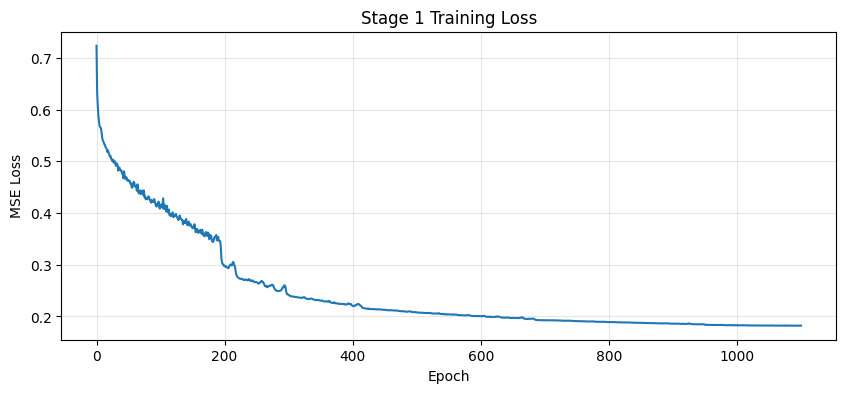

In [10]:
model_stage1, lossgraph_stage1 = train_on_fixed_windows(
    raw_processed, window_size=WINDOW_SIZE, epochs=EPOCHS, device=device
)
torch.save(model_stage1.state_dict(), 'remap_model_stage1.pth')
print("Stage 1 model saved.")

plt.figure(figsize=(10, 4))
plt.plot(lossgraph_stage1)
plt.title('Stage 1 Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.show()

0|100000|Computed loss at 52465 positions
Loss stats — mean: 0.5869, std: 0.6892, max: 15.3777


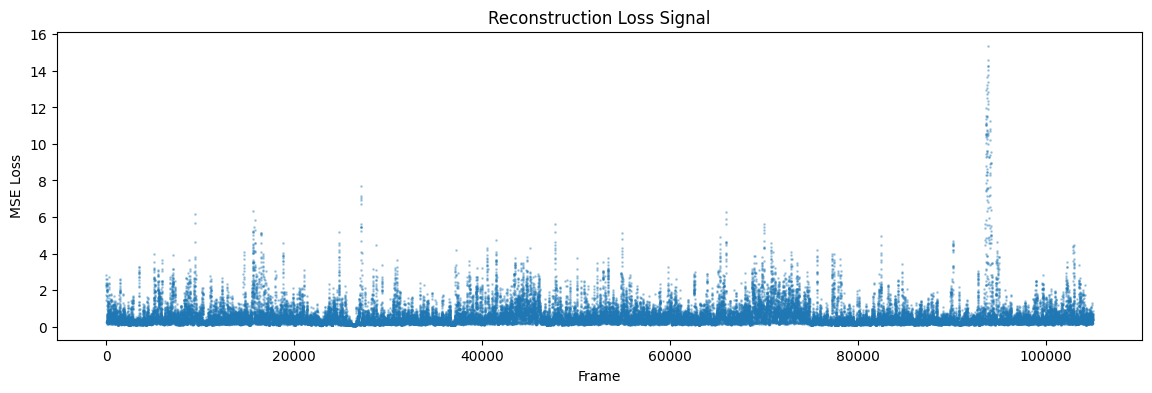

In [11]:
positions, losses = compute_frame_loss(
    model_stage1, raw_processed,
    window_size=WINDOW_SIZE, stride=2, device=device
)
np.save('remap_positions.npy', positions)
np.save('remap_losses.npy', losses)

plt.figure(figsize=(14, 4))
plt.plot(positions, losses, '.', markersize=2, alpha=0.3)
plt.title('Reconstruction Loss Signal')
plt.xlabel('Frame')
plt.ylabel('MSE Loss')
plt.show()

In [21]:
from sklearn.metrics import adjusted_rand_score
from collections import Counter

search_space = [
    Real(*PERCENTILE_RANGE, name='percentile'),
    Real(*QUANTILE_RANGE,   name='quantile'),
]
search_log   = []
best_results = None
best_score   = -1
iteration    = 0

@use_named_args(search_space)
def objective(percentile, quantile):
    global iteration, best_score, best_results
    iteration += 1
    print(f"\n{'='*60}")
    print(f"ITER {iteration}/{MAX_ITER} | percentile={percentile:.2f}, quantile={quantile:.4f}")
    print(f"{'='*60}")

    transition_frames, smoothed = find_transitions(
        positions, losses, percentile=percentile, fps=25
    )
    windows, _window_segment_labels, window_starts = create_windows_from_transitions(
        raw_processed, transition_frames,
        min_segment_frames=60, max_segment_frames=600
    )
    if len(windows) < 10:
        print(f"  too few windows ({len(windows)}) — skipping")
        return 0.0

    window_angle_labels_trial = []
    for win_idx in range(len(windows)):
        abs_start = window_starts[win_idx]
        abs_end   = abs_start + len(windows[win_idx])
        frame_angles = angle_per_frame[abs_start:abs_end]
        vals, counts = np.unique(frame_angles, return_counts=True)
        window_angle_labels_trial.append(vals[np.argmax(counts)])
    window_angle_labels_trial = np.array(window_angle_labels_trial)

    known_mask = window_angle_labels_trial != 'unknown'
    n_unknown  = (~known_mask).sum()
    if n_unknown > 0:
        print(f"  {n_unknown}/{len(windows)} windows have unknown ground truth — excluded from ARI")

    model_file = f"remap_model_stage2_{iteration}.pth"
    if Path(model_file).is_file():
        n_joints, joint_dim = raw_processed.shape[1], raw_processed.shape[2]
        checkpoint = torch.load(model_file, weights_only=True)
        saved_latent_dim = checkpoint['fc_latent.weight'].shape[0]
        model_stage2 = HierarchicalRAE(
            latent_dim=saved_latent_dim, joint_dim=joint_dim, num_joints=n_joints
        ).to(device)
        model_stage2.load_state_dict(checkpoint)
        print(f"Loaded cached model (latent_dim={saved_latent_dim}).")
    else:
        model_stage2, _ = train_on_variable_windows(
            raw_processed, windows, epochs=VW_EPOCHS, lr=LR, device=device
        )
        torch.save(model_stage2.state_dict(), model_file)

    latents, latents_2d, cluster_labels, ms_model = encode_and_cluster(
        model_stage2, windows, quantile=quantile,
        umap_neighbors=15, umap_min_dist=0.1, device=device
    )
    n_clusters = len(np.unique(cluster_labels))

    if n_clusters < 2 or n_clusters >= len(latents_2d) or known_mask.sum() < 2:
        print(f"  → {n_clusters} clusters — invalid, skipping")
        score = -1.0
    else:
        score = adjusted_rand_score(
            window_angle_labels_trial[known_mask],
            cluster_labels[known_mask]
        )

    search_log.append({
        'iteration':  iteration,
        'percentile': round(percentile, 2),
        'quantile':   round(quantile, 4),
        'n_clusters': n_clusters,
        'n_unknown':  int(n_unknown),
        'ari':        round(float(score), 4),
    })
    print(f"  → {n_clusters} clusters, ARI={score:.4f}")

    if score > best_score:
        best_score = score
        best_results = {
            'model':                    model_stage2,
            'model_stage1':             model_stage1,
            'latents':                  latents,
            'latents_2d':               latents_2d,
            'cluster_labels':           cluster_labels,
            'transition_frames':        transition_frames,
            'windows':                  windows,
            'window_starts':            window_starts,
            'window_angle_labels':      window_angle_labels_trial,
            '_percentile':              percentile,
            '_quantile':                quantile,
        }
        print(f"  ** NEW BEST (ARI={score:.4f}) **")

    del model_stage2, latents, latents_2d, cluster_labels, ms_model
    import gc; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return -score

bayes_result = gp_minimize(
    func=objective, dimensions=search_space,
    n_calls=MAX_ITER, n_initial_points=min(MAX_ITER, 5),
    random_state=42
)
print(f"\n{'='*60}\nSEARCH COMPLETE")
for entry in search_log:
    m = ' <-- BEST' if entry['ari'] == best_score else ''
    print(f"  Iter {entry['iteration']:2d}: percentile={entry['percentile']:5.2f}, "
          f"quantile={entry['quantile']:.4f}  → {entry['n_clusters']} clusters, "
          f"ARI={entry['ari']:.4f} ({entry['n_unknown']} unknown windows excluded){m}")
results = best_results


ITER 1/30 | percentile=67.79, quantile=0.1367
Found 4059 transitions
Mean bout duration: 1.03s
Bout duration looks plausible
Created 424 variable-length windows from 4060 segments
Window lengths — min: 60, max: 600, mean: 126.2
Loaded cached model (latent_dim=64).
Latents shape: (424, 64)
Running UMAP...


/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (424, 2)
Estimated bandwidth: 0.0276
Found 5 clusters
Cluster sizes: [186 124  63  34  17]
Silhouette score: 0.7413
  → 5 clusters, ARI=0.0148
  ** NEW BEST (ARI=0.0148) **

ITER 2/30 | percentile=66.78, quantile=0.2194
Found 4164 transitions
Mean bout duration: 1.01s
Bout duration looks plausible
Created 416 variable-length windows from 4165 segments
Window lengths — min: 60, max: 600, mean: 124.8
Loaded cached model (latent_dim=64).
Latents shape: (416, 64)
Running UMAP...


/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (416, 2)
Estimated bandwidth: 0.1106
Found 3 clusters
Cluster sizes: [222  95  99]
Silhouette score: 0.8786
  → 3 clusters, ARI=0.2593
  ** NEW BEST (ARI=0.2593) **

ITER 3/30 | percentile=46.75, quantile=0.1200
Found 6260 transitions
Mean bout duration: 0.67s
Created 252 variable-length windows from 6261 segments
Window lengths — min: 60, max: 600, mean: 101.4
Loaded cached model (latent_dim=64).
Latents shape: (252, 64)
Running UMAP...


...

UMAP done. Shape: (408, 2)
Estimated bandwidth: 0.0505
Found 3 clusters
Cluster sizes: [214 107  87]
Silhouette score: 0.8808
  → 3 clusters, ARI=0.1107

ITER 29/30 | percentile=67.82, quantile=0.2216
Found 4055 transitions
Mean bout duration: 1.04s
Bout duration looks plausible
Created 424 variable-length windows from 4056 segments
Window lengths — min: 60, max: 600, mean: 126.2
Retraining on variable-length windows...
Epoch 10/1000 — Loss: 0.565678  patience: 0/30
Epoch 20/1000 — Loss: 0.525265  patience: 0/30
Epoch 30/1000 — Loss: 0.495557  patience: 0/30
Epoch 40/1000 — Loss: 0.469962  patience: 0/30
Epoch 50/1000 — Loss: 0.439884  patience: 0/30
Epoch 60/1000 — Loss: 0.425954  patience: 0/30
Epoch 70/1000 — Loss: 0.403794  patience: 0/30
Epoch 80/1000 — Loss: 0.395524  patience: 0/30
Epoch 90/1000 — Loss: 0.395020  patience: 0/30
Epoch 100/1000 — Loss: 0.392236  patience: 5/30
Epoch 110/1000 — Loss: 0.374282  patience: 0/30
Epoch 120/1000 — Loss: 0.377238  patience: 10/30
Epoch 13

/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (424, 2)
Estimated bandwidth: 0.1383
Found 4 clusters
Cluster sizes: [146  95  87  96]
Silhouette score: 0.8125
  → 4 clusters, ARI=0.1699

ITER 30/30 | percentile=67.82, quantile=0.2216
Found 4054 transitions
Mean bout duration: 1.04s
Bout duration looks plausible
Created 424 variable-length windows from 4055 segments
Window lengths — min: 60, max: 600, mean: 126.3
Retraining on variable-length windows...
Epoch 10/1000 — Loss: 0.556816  patience: 1/30
Epoch 20/1000 — Loss: 0.531847  patience: 0/30
Epoch 30/1000 — Loss: 0.505585  patience: 0/30
Epoch 40/1000 — Loss: 0.468999  patience: 0/30
Epoch 50/1000 — Loss: 0.450724  patience: 0/30
Epoch 60/1000 — Loss: 0.419025  patience: 1/30
Epoch 70/1000 — Loss: 0.422632  patience: 7/30
Epoch 80/1000 — Loss: 0.397524  patience: 1/30
Epoch 90/1000 — Loss: 0.400431  patience: 6/30
Epoch 100/1000 — Loss: 0.379964  patience: 0/30
Epoch 110/1000 — Loss: 0.373322  patience: 0/30
Epoch 120/1000 — Loss: 0.378011  patience: 6/30
Epoch

/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (424, 2)
Estimated bandwidth: 0.1601
Found 3 clusters
Cluster sizes: [204 136  84]
Silhouette score: 0.8978
  → 3 clusters, ARI=0.1469

SEARCH COMPLETE
  Iter  1: percentile=67.79, quantile=0.1367  → 5 clusters, ARI=0.0148 (0 unknown windows excluded)
  Iter  2: percentile=66.78, quantile=0.2194  → 3 clusters, ARI=0.2593 (0 unknown windows excluded)
  Iter  3: percentile=46.75, quantile=0.1200  → 7 clusters, ARI=0.2227 (0 unknown windows excluded)
  Iter  4: percentile=47.55, quantile=0.1667  → 4 clusters, ARI=0.1704 (0 unknown windows excluded)
  Iter  5: percentile=28.57, quantile=0.2302  → 3 clusters, ARI=0.1265 (0 unknown windows excluded)
  Iter  6: percentile=66.70, quantile=0.2257  → 3 clusters, ARI=0.1491 (0 unknown windows excluded)
  Iter  7: percentile=69.24, quantile=0.2140  → 3 clusters, ARI=0.1327 (0 unknown windows excluded)
  Iter  8: percentile=66.58, quantile=0.2185  → 2 clusters, ARI=-0.0178 (0 unknown windows excluded)
  Iter  9: percentile=46.75, 

In [15]:
results = best_results

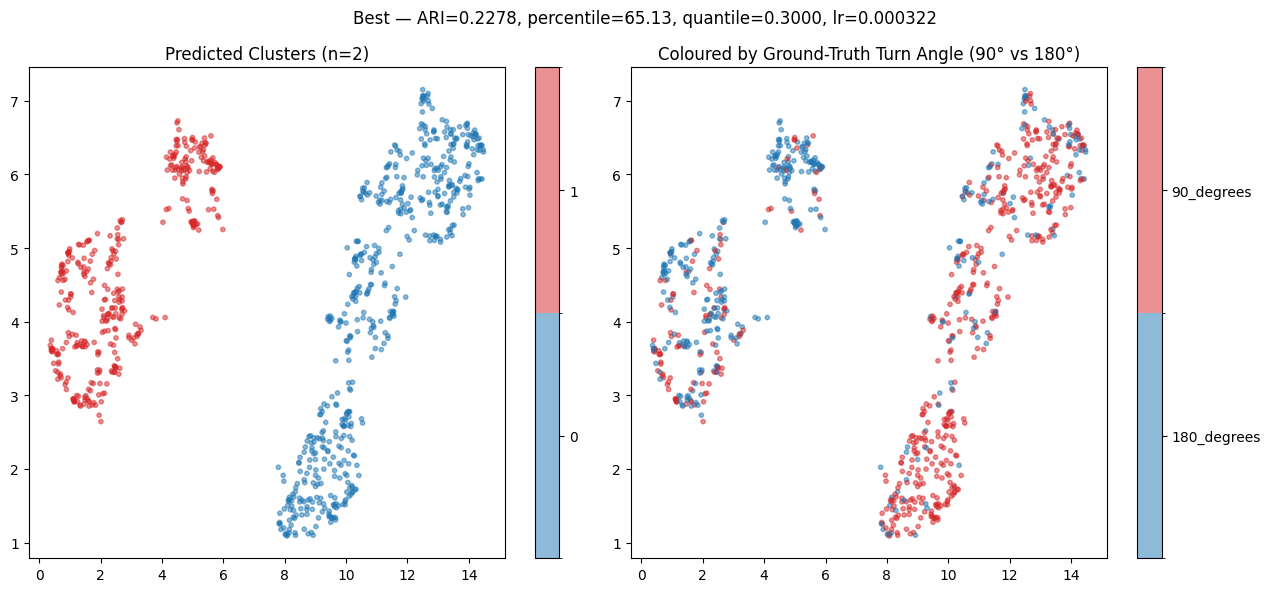

In [29]:
# ── plot ───────────────────────────────────────────────────────────────────
from matplotlib.colors import ListedColormap, BoundaryNorm

latents_2d         = results['latents_2d']
cluster_labels_new = results['cluster_labels']

two_color_cmap = ListedColormap(['#1f77b4', '#d62728'])  # pick any 2 colors you like

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# --- left: predicted clusters ---
unique_clusters = sorted(np.unique(cluster_labels_new))
cluster_to_int = {c: i for i, c in enumerate(unique_clusters)}
cluster_ints = np.array([cluster_to_int[c] for c in cluster_labels_new])
norm_clusters = BoundaryNorm(np.arange(-0.5, len(unique_clusters) + 0.5, 1), two_color_cmap.N)

scatter = axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1],
                           c=cluster_ints, cmap=two_color_cmap, norm=norm_clusters,
                           alpha=0.5, s=10)
axes[0].set_title(f"Predicted Clusters (n={len(unique_clusters)})")
cbar0 = plt.colorbar(scatter, ax=axes[0], ticks=range(len(unique_clusters)))
cbar0.ax.set_yticklabels(unique_clusters)

# --- right: ground-truth turn angle ---
window_angle_labels = results['window_angle_labels']
unique_angles = sorted(set(window_angle_labels))
angle_to_int = {a: i for i, a in enumerate(unique_angles)}
angle_ints = np.array([angle_to_int[a] for a in window_angle_labels])
norm_angles = BoundaryNorm(np.arange(-0.5, len(unique_angles) + 0.5, 1), two_color_cmap.N)

sc = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1],
                      c=angle_ints, cmap=two_color_cmap, norm=norm_angles,
                      alpha=0.5, s=10)
axes[1].set_title("Coloured by Ground-Truth Turn Angle (90° vs 180°)")
cbar1 = plt.colorbar(sc, ax=axes[1], ticks=range(len(unique_angles)))
cbar1.ax.set_yticklabels(unique_angles)

plt.suptitle(f"Best — ARI={best_score:.4f}, "
             f"percentile={results['_percentile']:.2f}, "
             f"quantile={results['_quantile']:.4f}, "
             f"lr={results['_lr']:.6f}")
plt.tight_layout()
plt.show()

STEP 1: Balancing windows based on existing clusters
Original cluster sizes: [213 165  48]
Total windows: 426
Target size per cluster: 165
  Cluster 0:   213 →   165 windows
  Cluster 1:   165 →   165 windows
  Cluster 2:    48 →    48 windows

Balanced dataset: 378 windows total

STEP 2: Bayesian optimization over lr, quantile, percentile

ITERATION 1/10  |  percentile=59.83, quantile=0.0959, lr=0.003626
Found 4924 transitions
Mean bout duration: 0.71s
Created 918 variable-length windows from 4925 segments
Window lengths — min: 24, max: 300, mean: 68.0
  Training on 378 balanced windows...
Retraining on variable-length windows...
Epoch 10/1000 — Loss: 0.570009  patience: 1/30
Epoch 20/1000 — Loss: 0.525514  patience: 2/30
Epoch 30/1000 — Loss: 0.484646  patience: 0/30
Epoch 40/1000 — Loss: 0.459627  patience: 1/30
Epoch 50/1000 — Loss: 0.434101  patience: 1/30
Epoch 60/1000 — Loss: 0.423574  patience: 0/30
Epoch 70/1000 — Loss: 0.409135  patience: 0/30
Epoch 80/1000 — Loss: 0.400481  

/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (918, 2)
Estimated bandwidth: 0.0555
Found 8 clusters
Cluster sizes: [232 123 127  82 108  78  94  74]
Silhouette score: 0.7420
  → 8 clusters, ARI=0.0130
  ** NEW BEST (ARI=0.0130) **

ITERATION 2/10  |  percentile=49.84, quantile=0.1615, lr=0.000158
Found 5947 transitions
Mean bout duration: 0.59s
Created 877 variable-length windows from 5948 segments
Window lengths — min: 24, max: 300, mean: 58.2
  Training on 378 balanced windows...
Retraining on variable-length windows...
Epoch 10/1000 — Loss: 0.591292  patience: 0/30
Epoch 20/1000 — Loss: 0.562371  patience: 0/30
Epoch 30/1000 — Loss: 0.548120  patience: 0/30
Epoch 40/1000 — Loss: 0.533352  patience: 0/30
Epoch 50/1000 — Loss: 0.509248  patience: 0/30
Epoch 60/1000 — Loss: 0.494314  patience: 0/30
Epoch 70/1000 — Loss: 0.481755  patience: 0/30
Epoch 80/1000 — Loss: 0.480998  patience: 0/30
Epoch 90/1000 — Loss: 0.467768  patience: 4/30
Epoch 100/1000 — Loss: 0.456326  patience: 1/30
Epoch 110/1000 — Loss: 0.4552

/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (877, 2)
Estimated bandwidth: 0.0896
Found 5 clusters
Cluster sizes: [361 177 117 139  83]
Silhouette score: 0.7803
  → 5 clusters, ARI=0.0860
  ** NEW BEST (ARI=0.0860) **

ITERATION 3/10  |  percentile=42.96, quantile=0.1334, lr=0.000193
Found 6613 transitions
Mean bout duration: 0.53s
Created 810 variable-length windows from 6614 segments
Window lengths — min: 24, max: 300, mean: 53.4
  Training on 378 balanced windows...
Retraining on variable-length windows...
Epoch 10/1000 — Loss: 0.585344  patience: 0/30
Epoch 20/1000 — Loss: 0.557951  patience: 0/30
Epoch 30/1000 — Loss: 0.542508  patience: 1/30
Epoch 40/1000 — Loss: 0.524908  patience: 0/30
Epoch 50/1000 — Loss: 0.503228  patience: 0/30
Epoch 60/1000 — Loss: 0.496260  patience: 2/30
Epoch 70/1000 — Loss: 0.477074  patience: 0/30
Epoch 80/1000 — Loss: 0.464461  patience: 1/30
Epoch 90/1000 — Loss: 0.452301  patience: 0/30
Epoch 100/1000 — Loss: 0.449320  patience: 0/30
Epoch 110/1000 — Loss: 0.439058  patience

...

UMAP done. Shape: (602, 2)
Estimated bandwidth: 0.1069
Found 3 clusters
Cluster sizes: [335 118 149]
Silhouette score: 0.9180
  → 3 clusters, ARI=0.1799

ITERATION 9/10  |  percentile=38.77, quantile=0.1972, lr=0.003255
Found 6977 transitions
Mean bout duration: 0.50s
Created 735 variable-length windows from 6978 segments
Window lengths — min: 24, max: 300, mean: 52.3
  Training on 378 balanced windows...
Retraining on variable-length windows...
Epoch 10/1000 — Loss: 0.575625  patience: 1/30
Epoch 20/1000 — Loss: 0.521635  patience: 0/30
Epoch 30/1000 — Loss: 0.466123  patience: 0/30
Epoch 40/1000 — Loss: 0.432949  patience: 0/30
Epoch 50/1000 — Loss: 0.413367  patience: 0/30
Epoch 60/1000 — Loss: 0.399755  patience: 2/30
Epoch 70/1000 — Loss: 0.381410  patience: 0/30
Epoch 80/1000 — Loss: 0.377268  patience: 2/30
Epoch 90/1000 — Loss: 0.367031  patience: 2/30
Epoch 100/1000 — Loss: 0.358833  patience: 0/30
Epoch 110/1000 — Loss: 0.364680  patience: 2/30
Epoch 120/1000 — Loss: 0.361334

/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (735, 2)
Estimated bandwidth: 0.1064
Found 3 clusters
Cluster sizes: [313 287 135]
Silhouette score: 0.8580
  → 3 clusters, ARI=0.1186

ITERATION 10/10  |  percentile=69.83, quantile=0.1827, lr=0.000216
Found 3827 transitions
Mean bout duration: 0.91s
Created 894 variable-length windows from 3828 segments
Window lengths — min: 24, max: 300, mean: 82.7
  Training on 378 balanced windows...
Retraining on variable-length windows...
Epoch 10/1000 — Loss: 0.581088  patience: 0/30
Epoch 20/1000 — Loss: 0.556163  patience: 0/30
Epoch 30/1000 — Loss: 0.536949  patience: 0/30
Epoch 40/1000 — Loss: 0.517353  patience: 0/30
Epoch 50/1000 — Loss: 0.494917  patience: 0/30
Epoch 60/1000 — Loss: 0.477583  patience: 0/30
Epoch 70/1000 — Loss: 0.465902  patience: 0/30
Epoch 80/1000 — Loss: 0.456158  patience: 0/30
Epoch 90/1000 — Loss: 0.452942  patience: 3/30
Epoch 100/1000 — Loss: 0.439411  patience: 0/30
Epoch 110/1000 — Loss: 0.432847  patience: 0/30
Epoch 120/1000 — Loss: 0.42740

/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (894, 2)
Estimated bandwidth: 0.2444
Found 6 clusters
Cluster sizes: [410 232 161  56  33   2]
Silhouette score: 0.7875
  → 6 clusters, ARI=0.0976

OPTIMIZATION COMPLETE
  Iter  1: percentile=59.83, quantile=0.0959, lr=0.003626  →  8 clusters, ARI=0.0130 (0 unknown excluded)
  Iter  2: percentile=49.84, quantile=0.1615, lr=0.000158  →  5 clusters, ARI=0.0860 (0 unknown excluded)
  Iter  3: percentile=42.96, quantile=0.1334, lr=0.000193  →  6 clusters, ARI=0.0367 (0 unknown excluded)
  Iter  4: percentile=52.54, quantile=0.0641, lr=0.002780  →  15 clusters, ARI=0.0334 (0 unknown excluded)
  Iter  5: percentile=66.93, quantile=0.0502, lr=0.009648  →  19 clusters, ARI=0.0130 (0 unknown excluded)
  Iter  6: percentile=52.41, quantile=0.1928, lr=0.000100  →  3 clusters, ARI=0.1985 (0 unknown excluded)
  Iter  7: percentile=51.74, quantile=0.2154, lr=0.000100  →  3 clusters, ARI=0.0503 (0 unknown excluded)
  Iter  8: percentile=30.05, quantile=0.1846, lr=0.005823  →  3 clus

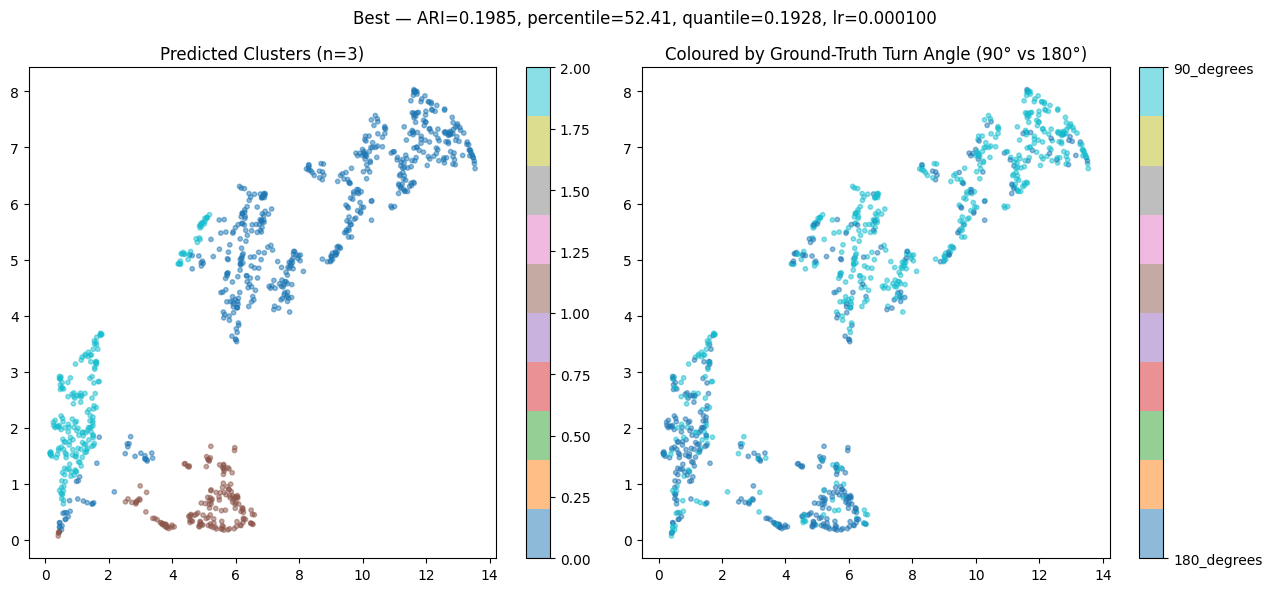

In [24]:
import gc
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

# ── Step 1: balance windows based on EXISTING cluster labels ───────────────
print("="*60)
print("STEP 1: Balancing windows based on existing clusters")
print("="*60)

cluster_labels_original = results['cluster_labels']
cluster_sizes_original  = np.bincount(cluster_labels_original)
print(f"Original cluster sizes: {cluster_sizes_original}")
print(f"Total windows: {len(cluster_labels_original)}")

target_size = int(np.median(cluster_sizes_original))
print(f"Target size per cluster: {target_size}")

np.random.seed(42)
balanced_indices = []
for c in np.unique(cluster_labels_original):
    idx    = np.where(cluster_labels_original == c)[0]
    chosen = np.random.choice(idx, min(target_size, len(idx)), replace=False)
    balanced_indices.extend(chosen)
    print(f"  Cluster {c}: {len(idx):5d} → {min(target_size, len(idx)):5d} windows")

balanced_indices = np.array(balanced_indices)
balanced_windows = [results['windows'][i] for i in balanced_indices]
print(f"\nBalanced dataset: {len(balanced_windows)} windows total")

# ── Step 2: pull existing transition-detection inputs ──────────────────────
positions        = positions
losses           = losses
all_windows_orig = results['windows']   # full unbalanced window set

# angle_per_frame must already be in scope — built from Turning_human_labels.xlsx,
# one ground-truth turn-angle label per frame, aligned 1:1 with raw_processed
assert 'angle_per_frame' in dir(), "angle_per_frame not in scope — rerun the label-loading cell first"
assert len(angle_per_frame) == raw_processed.shape[0], \
    f"angle_per_frame length {len(angle_per_frame)} != raw_processed frames {raw_processed.shape[0]}"

# ── Step 3: Bayesian optimization ─────────────────────────────────────────
print("\n" + "="*60)
print("STEP 2: Bayesian optimization over lr, quantile, percentile")
print("="*60)

MAX_ITER     = 10
search_space = [
    Real(20, 70.0, name='percentile'),
    Real(0.05, 0.30, name='quantile'),
    Real(1e-4, 1e-2, name='lr', prior='log-uniform'),
]

search_log   = []
best_results = None
best_score   = -1
iteration    = 0

@use_named_args(search_space)
def objective(percentile, quantile, lr):
    global iteration, best_score, best_results

    iteration += 1
    print(f"\n{'='*60}")
    print(f"ITERATION {iteration}/{MAX_ITER}  |  "
          f"percentile={percentile:.2f}, "
          f"quantile={quantile:.4f}, "
          f"lr={lr:.6f}")
    print(f"{'='*60}")

    # find new transitions with this percentile
    transition_frames, smoothed = find_transitions(
        positions, losses, percentile=percentile, fps=30
    )

    # create new variable windows with these transitions
    new_windows, _window_segment_labels, window_starts = create_windows_from_transitions(
        raw_processed, transition_frames,
        min_segment_frames=24, max_segment_frames=300
    )

    if len(new_windows) < 10:
        print(f"  → too few windows ({len(new_windows)}) — skipping")
        return 0.0

    # ── rebuild REAL ground-truth turn-angle (90°/180°) labels for THIS trial's windows ──
    window_angle_labels_new = []
    for win_idx in range(len(new_windows)):
        abs_start = window_starts[win_idx]
        abs_end   = abs_start + len(new_windows[win_idx])
        frame_angles = angle_per_frame[abs_start:abs_end]
        vals, counts = np.unique(frame_angles, return_counts=True)
        window_angle_labels_new.append(vals[np.argmax(counts)])
    window_angle_labels_new = np.array(window_angle_labels_new)

    known_mask = window_angle_labels_new != 'unknown'
    n_unknown  = (~known_mask).sum()
    if n_unknown > 0:
        print(f"  {n_unknown}/{len(new_windows)} windows have unknown ground truth — excluded from ARI")

    train_windows = balanced_windows   # always train on balanced subset
    print(f"  Training on {len(train_windows)} balanced windows...")

    # retrain Stage 2 on balanced windows with this lr
    model_stage2, lossgraph_stage2 = train_on_variable_windows(
        raw_processed, train_windows,
        epochs = 1000,
        lr     = lr,
        device = device
    )

    # encode ALL new windows with trained model
    print(f"  Encoding {len(new_windows)} windows...")
    latents, latents_2d, cluster_labels_new, ms_model = encode_and_cluster(
        model_stage2, new_windows,   # ALL new windows
        quantile       = quantile,
        umap_neighbors = 15,
        umap_min_dist  = 0.0,
        device         = device
    )

    n_clusters = len(np.unique(cluster_labels_new))

    # ── ARI against REAL turn-angle (90°/180°) ground truth (known-label windows only) ──
    if n_clusters < 2 or n_clusters >= len(latents_2d) or known_mask.sum() < 2:
        print(f"  → {n_clusters} clusters — invalid")
        score = -1.0
    else:
        score = adjusted_rand_score(
            window_angle_labels_new[known_mask],
            cluster_labels_new[known_mask]
        )

    log_entry = {
        "iteration":  iteration,
        "percentile": round(percentile, 2),
        "quantile":   round(quantile, 4),
        "lr":         round(float(lr), 6),
        "n_clusters": n_clusters,
        "n_unknown":  int(n_unknown),
        "ari":        round(float(score), 4),
    }
    search_log.append(log_entry)
    print(f"  → {n_clusters} clusters, ARI={score:.4f}")

    if score > best_score:
        best_score = score
        best_results = {
            'model':                model_stage2,
            'model_stage1':         results['model_stage1'],
            'latents':              latents,
            'latents_2d':           latents_2d,
            'cluster_labels':       cluster_labels_new,
            'transition_frames':    transition_frames,
            'windows':              new_windows,
            'window_starts':        window_starts,
            'window_angle_labels':  window_angle_labels_new,
            'losses':               losses,
            'positions':            positions,
            'lossgraph_stage2':     lossgraph_stage2,
            'smoothed_losses':      smoothed,
            '_percentile':          percentile,
            '_quantile':            quantile,
            '_lr':                  lr,
        }
        print(f"  ** NEW BEST (ARI={score:.4f}) **")

    del model_stage2, latents, latents_2d, cluster_labels_new, ms_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return -score

# ── run optimization ───────────────────────────────────────────────────────
bayes_result = gp_minimize(
    func             = objective,
    dimensions       = search_space,
    n_calls          = MAX_ITER,
    n_initial_points = 5,
    random_state     = 42,
)

# ── summary ────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("OPTIMIZATION COMPLETE")
print(f"{'='*60}")
for entry in search_log:
    marker = " <-- BEST" if entry['ari'] == best_score else ""
    print(f"  Iter {entry['iteration']:2d}: "
          f"percentile={entry['percentile']:5.2f}, "
          f"quantile={entry['quantile']:.4f}, "
          f"lr={entry['lr']:.6f}  "
          f"→  {entry['n_clusters']} clusters, "
          f"ARI={entry['ari']:.4f} ({entry['n_unknown']} unknown excluded){marker}")

print(f"\nBest parameters:")
print(f"  percentile:  {best_results['_percentile']:.2f}")
print(f"  quantile:    {best_results['_quantile']:.4f}")
print(f"  lr:          {best_results['_lr']:.6f}")
print(f"  n_clusters:  {len(np.unique(best_results['cluster_labels']))}")
print(f"  ARI:         {best_score:.4f}")

# ── set results to best ────────────────────────────────────────────────────
results = best_results

# ── plot ───────────────────────────────────────────────────────────────────
latents_2d         = results['latents_2d']
cluster_labels_new = results['cluster_labels']

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

scatter = axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1],
                           c=cluster_labels_new, cmap='tab10', alpha=0.5, s=10)
axes[0].set_title(f"Predicted Clusters (n={len(np.unique(cluster_labels_new))})")
plt.colorbar(scatter, ax=axes[0])

window_angle_labels = results['window_angle_labels']
unique_angles = sorted(set(window_angle_labels))
angle_to_int = {a: i for i, a in enumerate(unique_angles)}
angle_ints = np.array([angle_to_int[a] for a in window_angle_labels])
sc = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1],
                      c=angle_ints, cmap='tab10', alpha=0.5, s=10)
axes[1].set_title("Coloured by Ground-Truth Turn Angle (90° vs 180°)")
cbar = plt.colorbar(sc, ax=axes[1], ticks=range(len(unique_angles)))
cbar.ax.set_yticklabels(unique_angles)

plt.suptitle(f"Best — ARI={best_score:.4f}, "
             f"percentile={results['_percentile']:.2f}, "
             f"quantile={results['_quantile']:.4f}, "
             f"lr={results['_lr']:.6f}")
plt.tight_layout()
plt.show()

In [25]:
import gc
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

# ── continue optimization for 20 more iterations ────────────────────────────
# reuses: balanced_windows, positions, losses, angle_per_frame, raw_processed,
# device, results (current best), best_score, best_results, search_log,
# search_space, objective(), iteration — all must already be in scope from
# the previous run.

assert 'search_log' in dir(), "search_log not in scope — run the original optimization cell first"
assert 'best_results' in dir(), "best_results not in scope — run the original optimization cell first"

ADDITIONAL_ITER = 20

print("="*60)
print(f"RESUMING OPTIMIZATION — {ADDITIONAL_ITER} more iterations")
print(f"Starting from iteration {iteration}, current best ARI={best_score:.4f}")
print("="*60)

# rebuild x0/y0 from the existing search_log so gp_minimize resumes instead
# of restarting the surrogate model from scratch
x0 = [[e['percentile'], e['quantile'], e['lr']] for e in search_log]
y0 = [-e['ari'] for e in search_log]   # objective() returns -score, so match sign

bayes_result_2 = gp_minimize(
    func             = objective,
    dimensions       = search_space,
    n_calls          = ADDITIONAL_ITER,
    n_initial_points = 0,     # no fresh random points — we already have history
    x0               = x0,
    y0               = y0,
    random_state     = 42,
)

# ── summary ────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("EXTENDED OPTIMIZATION COMPLETE")
print(f"{'='*60}")
for entry in search_log:
    marker = " <-- BEST" if entry['ari'] == best_score else ""
    print(f"  Iter {entry['iteration']:2d}: "
          f"percentile={entry['percentile']:5.2f}, "
          f"quantile={entry['quantile']:.4f}, "
          f"lr={entry['lr']:.6f}  "
          f"→  {entry['n_clusters']} clusters, "
          f"ARI={entry['ari']:.4f} ({entry['n_unknown']} unknown excluded){marker}")

print(f"\nBest parameters (after {iteration} total iterations):")
print(f"  percentile:  {best_results['_percentile']:.2f}")
print(f"  quantile:    {best_results['_quantile']:.4f}")
print(f"  lr:          {best_results['_lr']:.6f}")
print(f"  n_clusters:  {len(np.unique(best_results['cluster_labels']))}")
print(f"  ARI:         {best_score:.4f}")

# ── set results to best ────────────────────────────────────────────────────
results = best_results

# ── plot ───────────────────────────────────────────────────────────────────
latents_2d         = results['latents_2d']
cluster_labels_new = results['cluster_labels']

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

scatter = axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1],
                           c=cluster_labels_new, cmap='tab10', alpha=0.5, s=10)
axes[0].set_title(f"Predicted Clusters (n={len(np.unique(cluster_labels_new))})")
plt.colorbar(scatter, ax=axes[0])

turn_angle_labels = results['turn_angle_labels']
unique_angles = sorted(set(turn_angle_labels))
angle_to_int = {a: i for i, a in enumerate(unique_angles)}
angle_ints = np.array([angle_to_int[a] for a in turn_angle_labels])
sc = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1],
                      c=angle_ints, cmap='tab10', alpha=0.5, s=10)
axes[1].set_title("Coloured by Ground-Truth Turn Angle")
cbar = plt.colorbar(sc, ax=axes[1], ticks=range(len(unique_angles)))
cbar.ax.set_yticklabels(unique_angles)

plt.suptitle(f"Best — ARI={best_score:.4f}, "
             f"percentile={results['_percentile']:.2f}, "
             f"quantile={results['_quantile']:.4f}, "
             f"lr={results['_lr']:.6f}")
plt.tight_layout()
plt.show()

RESUMING OPTIMIZATION — 20 more iterations
Starting from iteration 10, current best ARI=0.1985

ITERATION 11/10  |  percentile=20.00, quantile=0.1853, lr=0.000255
Found 8460 transitions
Mean bout duration: 0.41s
Created 472 variable-length windows from 8461 segments
Window lengths — min: 24, max: 300, mean: 43.8
  Training on 378 balanced windows...
Retraining on variable-length windows...
Epoch 10/1000 — Loss: 0.580998  patience: 0/30
Epoch 20/1000 — Loss: 0.555051  patience: 0/30
Epoch 30/1000 — Loss: 0.539387  patience: 0/30
Epoch 40/1000 — Loss: 0.522436  patience: 0/30
Epoch 50/1000 — Loss: 0.510033  patience: 0/30
Epoch 60/1000 — Loss: 0.493942  patience: 2/30
Epoch 70/1000 — Loss: 0.472776  patience: 2/30
Epoch 80/1000 — Loss: 0.463082  patience: 4/30
Epoch 90/1000 — Loss: 0.450336  patience: 0/30
Epoch 100/1000 — Loss: 0.444982  patience: 5/30
Epoch 110/1000 — Loss: 0.434260  patience: 0/30
Epoch 120/1000 — Loss: 0.429186  patience: 0/30
Epoch 130/1000 — Loss: 0.421466  patienc

/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (472, 2)
Estimated bandwidth: 0.2541
Found 5 clusters
Cluster sizes: [195 135  60  46  36]
Silhouette score: 0.8451
  → 5 clusters, ARI=0.0974

ITERATION 12/10  |  percentile=54.13, quantile=0.1763, lr=0.010000
Found 5502 transitions
Mean bout duration: 0.64s
Created 902 variable-length windows from 5503 segments
Window lengths — min: 24, max: 300, mean: 62.2
  Training on 378 balanced windows...
Retraining on variable-length windows...
Epoch 10/1000 — Loss: 0.556234  patience: 0/30
Epoch 20/1000 — Loss: 0.542078  patience: 3/30
Epoch 30/1000 — Loss: 0.527654  patience: 6/30
Epoch 40/1000 — Loss: 0.498462  patience: 0/30
Epoch 50/1000 — Loss: 0.482473  patience: 0/30
Epoch 60/1000 — Loss: 0.472413  patience: 4/30
Epoch 70/1000 — Loss: 0.463354  patience: 6/30
Epoch 80/1000 — Loss: 0.450691  patience: 0/30
Epoch 90/1000 — Loss: 0.448624  patience: 7/30
Epoch 100/1000 — Loss: 0.440806  patience: 2/30
Epoch 110/1000 — Loss: 0.427724  patience: 0/30
Epoch 120/1000 — Loss:

/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (902, 2)
Estimated bandwidth: 0.1678
Found 4 clusters
Cluster sizes: [384 275 157  86]
Silhouette score: 0.8193
  → 4 clusters, ARI=0.0263

ITERATION 13/10  |  percentile=69.45, quantile=0.1915, lr=0.001337
Found 3871 transitions
Mean bout duration: 0.90s
Created 896 variable-length windows from 3872 segments
Window lengths — min: 24, max: 300, mean: 82.0
  Training on 378 balanced windows...
Retraining on variable-length windows...
Epoch 10/1000 — Loss: 0.561889  patience: 1/30
Epoch 20/1000 — Loss: 0.518894  patience: 0/30
Epoch 30/1000 — Loss: 0.499725  patience: 2/30
Epoch 40/1000 — Loss: 0.466447  patience: 0/30
Epoch 50/1000 — Loss: 0.439943  patience: 2/30
Epoch 60/1000 — Loss: 0.413532  patience: 0/30
Epoch 70/1000 — Loss: 0.405873  patience: 1/30
Epoch 80/1000 — Loss: 0.388032  patience: 0/30
Epoch 90/1000 — Loss: 0.390715  patience: 10/30
Epoch 100/1000 — Loss: 0.377118  patience: 1/30
Epoch 110/1000 — Loss: 0.372567  patience: 0/30
Epoch 120/1000 — Loss: 0.

...

/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (476, 2)
Estimated bandwidth: 0.1546
Found 3 clusters
Cluster sizes: [202 131 143]
Silhouette score: 0.8761
  → 3 clusters, ARI=0.0835

ITERATION 20/10  |  percentile=62.51, quantile=0.2846, lr=0.000100
Found 4626 transitions
Mean bout duration: 0.76s
Created 918 variable-length windows from 4627 segments
Window lengths — min: 24, max: 300, mean: 71.6
  Training on 378 balanced windows...
Retraining on variable-length windows...
Epoch 10/1000 — Loss: 0.607875  patience: 0/30
Epoch 20/1000 — Loss: 0.573019  patience: 0/30
Epoch 30/1000 — Loss: 0.558100  patience: 0/30
Epoch 40/1000 — Loss: 0.543494  patience: 0/30
Epoch 50/1000 — Loss: 0.531898  patience: 1/30
Epoch 60/1000 — Loss: 0.522476  patience: 0/30
Epoch 70/1000 — Loss: 0.510932  patience: 0/30
Epoch 80/1000 — Loss: 0.500428  patience: 0/30
Epoch 90/1000 — Loss: 0.486479  patience: 0/30
Epoch 100/1000 — Loss: 0.477019  patience: 0/30
Epoch 110/1000 — Loss: 0.470660  patience: 0/30
Epoch 120/1000 — Loss: 0.46234

/opt/miniconda3/envs/ma_v1/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (918, 2)
Estimated bandwidth: 0.1865
Found 2 clusters
Cluster sizes: [446 472]
Silhouette score: 0.8592
  → 2 clusters, ARI=0.1529

ITERATION 21/10  |  percentile=28.47, quantile=0.2452, lr=0.001856
Found 7867 transitions
Mean bout duration: 0.44s
Created 583 variable-length windows from 7868 segments
Window lengths — min: 24, max: 300, mean: 47.5
  Training on 378 balanced windows...
Retraining on variable-length windows...
Epoch 10/1000 — Loss: 0.566515  patience: 0/30
Epoch 20/1000 — Loss: 0.527766  patience: 0/30
Epoch 30/1000 — Loss: 0.485609  patience: 0/30
Epoch 40/1000 — Loss: 0.447840  patience: 0/30
Epoch 50/1000 — Loss: 0.421447  patience: 0/30
Epoch 60/1000 — Loss: 0.407913  patience: 3/30
Epoch 70/1000 — Loss: 0.393089  patience: 0/30
Epoch 80/1000 — Loss: 0.384917  patience: 0/30
Epoch 90/1000 — Loss: 0.380331  patience: 4/30
Epoch 100/1000 — Loss: 0.377633  patience: 7/30
Epoch 110/1000 — Loss: 0.360698  patience: 0/30
Epoch 120/1000 — Loss: 0.365068  p

KeyboardInterrupt: 

In [26]:
results = best_results

In [ ]:
import gc
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

# ── continue optimization for 20 more iterations ────────────────────────────
# reuses: balanced_windows, positions, losses, angle_per_frame, raw_processed,
# device, results (current best), best_score, best_results, search_log,
# search_space, objective(), iteration — all must already be in scope from
# the previous run.

assert 'search_log' in dir(), "search_log not in scope — run the original optimization cell first"
assert 'best_results' in dir(), "best_results not in scope — run the original optimization cell first"

ADDITIONAL_ITER = 20

print("="*60)
print(f"RESUMING OPTIMIZATION — {ADDITIONAL_ITER} more iterations")
print(f"Starting from iteration {iteration}, current best ARI={best_score:.4f}")
print("="*60)

# rebuild x0/y0 from the existing search_log so gp_minimize resumes instead
# of restarting the surrogate model from scratch
x0 = [[e['percentile'], e['quantile'], e['lr']] for e in search_log]
y0 = [-e['ari'] for e in search_log]   # objective() returns -score, so match sign

bayes_result_2 = gp_minimize(
    func             = objective,
    dimensions       = search_space,
    n_calls          = ADDITIONAL_ITER,
    n_initial_points = 0,     # no fresh random points — we already have history
    x0               = x0,
    y0               = y0,
    random_state     = 42,
)

# ── summary ────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("EXTENDED OPTIMIZATION COMPLETE")
print(f"{'='*60}")
for entry in search_log:
    marker = " <-- BEST" if entry['ari'] == best_score else ""
    print(f"  Iter {entry['iteration']:2d}: "
          f"percentile={entry['percentile']:5.2f}, "
          f"quantile={entry['quantile']:.4f}, "
          f"lr={entry['lr']:.6f}  "
          f"→  {entry['n_clusters']} clusters, "
          f"ARI={entry['ari']:.4f} ({entry['n_unknown']} unknown excluded){marker}")

print(f"\nBest parameters (after {iteration} total iterations):")
print(f"  percentile:  {best_results['_percentile']:.2f}")
print(f"  quantile:    {best_results['_quantile']:.4f}")
print(f"  lr:          {best_results['_lr']:.6f}")
print(f"  n_clusters:  {len(np.unique(best_results['cluster_labels']))}")
print(f"  ARI:         {best_score:.4f}")

# ── set results to best ────────────────────────────────────────────────────
results = best_results

# ── plot ───────────────────────────────────────────────────────────────────
latents_2d         = results['latents_2d']
cluster_labels_new = results['cluster_labels']

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

scatter = axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1],
                           c=cluster_labels_new, cmap='tab10', alpha=0.5, s=10)
axes[0].set_title(f"Predicted Clusters (n={len(np.unique(cluster_labels_new))})")
plt.colorbar(scatter, ax=axes[0])

turn_angle_labels = results['turn_angle_labels']
unique_angles = sorted(set(turn_angle_labels))
angle_to_int = {a: i for i, a in enumerate(unique_angles)}
angle_ints = np.array([angle_to_int[a] for a in turn_angle_labels])
sc = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1],
                      c=angle_ints, cmap='tab10', alpha=0.5, s=10)
axes[1].set_title("Coloured by Ground-Truth Turn Angle")
cbar = plt.colorbar(sc, ax=axes[1], ticks=range(len(unique_angles)))
cbar.ax.set_yticklabels(unique_angles)

plt.suptitle(f"Best — ARI={best_score:.4f}, "
             f"percentile={results['_percentile']:.2f}, "
             f"quantile={results['_quantile']:.4f}, "
             f"lr={results['_lr']:.6f}")
plt.tight_layout()
plt.show()

In [ ]:
# ── plot ───────────────────────────────────────────────────────────────────
latents_2d         = results['latents_2d']
cluster_labels_new = results['cluster_labels']

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

scatter = axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1],
                           c=cluster_labels_new, cmap='tab10', alpha=0.5, s=10)
axes[0].set_title(f"Predicted Clusters (n={len(np.unique(cluster_labels_new))})")
plt.colorbar(scatter, ax=axes[0])

turn_angle_labels = results['window_angle_labels']
unique_angles = sorted(set(turn_angle_labels))
angle_to_int = {a: i for i, a in enumerate(unique_angles)}
angle_ints = np.array([angle_to_int[a] for a in turn_angle_labels])
sc = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1],
                      c=angle_ints, cmap='tab10', alpha=0.5, s=10)
axes[1].set_title("Coloured by Ground-Truth Turn Angle")
cbar = plt.colorbar(sc, ax=axes[1], ticks=range(len(unique_angles)))
cbar.ax.set_yticklabels(unique_angles)

plt.suptitle(f"Best — ARI={best_score:.4f}, "
             f"percentile={results['_percentile']:.2f}, "
             f"quantile={results['_quantile']:.4f}, "
             f"lr={results['_lr']:.6f}")
plt.tight_layout()
plt.show()

Excluding 0 windows with unknown ground truth

Confusion matrix (rows=true turn angle, cols=predicted cluster):
               0    1
180_degrees  123  253
90_degrees   417  113

Row-normalized (fraction of each true angle per cluster):
                 0      1
180_degrees  0.327  0.673
90_degrees   0.787  0.213

Best-matching accuracy (Hungarian assignment): 670/906 = 0.740
  true= 180_degrees  <->  cluster=1  (253 matched)
  true=  90_degrees  <->  cluster=0  (417 matched)


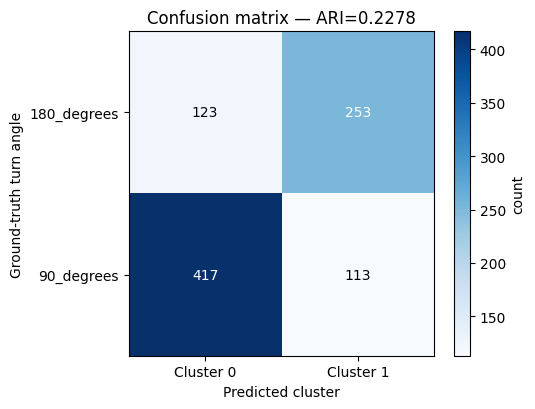

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cluster_labels_new = results['cluster_labels']
turn_angle_labels  = results['window_angle_labels']

# exclude 'unknown' ground-truth windows, same as during ARI scoring
known_mask = turn_angle_labels != 'unknown'
n_unknown  = (~known_mask).sum()
print(f"Excluding {n_unknown} windows with unknown ground truth")

true_known    = turn_angle_labels[known_mask]
pred_known    = cluster_labels_new[known_mask]
unique_angles = sorted(set(true_known))
unique_clusters = sorted(set(pred_known))

# ── raw counts table: rows = true angle, cols = predicted cluster ──────────
cm = confusion_matrix(true_known, pred_known,
                       labels=unique_angles)  # rows follow labels order
# confusion_matrix col order follows np.unique(pred_known) when labels not
# given for the pred side, so build explicitly instead for clarity:
cm_df = pd.DataFrame(0, index=unique_angles, columns=unique_clusters)
for t, p in zip(true_known, pred_known):
    cm_df.loc[t, p] += 1

print("\nConfusion matrix (rows=true turn angle, cols=predicted cluster):")
print(cm_df)

# ── row-normalized (% of each true angle going to each cluster) ────────────
cm_row_norm = cm_df.div(cm_df.sum(axis=1), axis=0)
print("\nRow-normalized (fraction of each true angle per cluster):")
print(cm_row_norm.round(3))

# ── overall accuracy under best true->cluster assignment ───────────────────
# clusters are unsupervised, so "accuracy" only makes sense after matching
# each cluster to its majority true label (Hungarian assignment)
from scipy.optimize import linear_sum_assignment

cost = -cm_df.values  # maximize overlap == minimize negative overlap
row_ind, col_ind = linear_sum_assignment(cost)
matched_correct = cm_df.values[row_ind, col_ind].sum()
total = cm_df.values.sum()
print(f"\nBest-matching accuracy (Hungarian assignment): "
      f"{matched_correct}/{total} = {matched_correct/total:.3f}")
for r, c in zip(row_ind, col_ind):
    print(f"  true={unique_angles[r]:>12s}  <->  cluster={unique_clusters[c]}"
          f"  ({cm_df.values[r, c]} matched)")

# ── heatmap plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(1.2 * len(unique_clusters) + 3,
                                 0.6 * len(unique_angles) + 3))
im = ax.imshow(cm_df.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(unique_clusters)))
ax.set_xticklabels([f"Cluster {c}" for c in unique_clusters])
ax.set_yticks(range(len(unique_angles)))
ax.set_yticklabels(unique_angles)
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("Ground-truth turn angle")
ax.set_title(f"Confusion matrix — ARI={adjusted_rand_score(true_known, pred_known):.4f}"
             if 'adjusted_rand_score' in dir() else "Confusion matrix")

# annotate counts
for i in range(len(unique_angles)):
    for j in range(len(unique_clusters)):
        val = cm_df.values[i, j]
        color = "white" if val > cm_df.values.max() / 2 else "black"
        ax.text(j, i, str(val), ha="center", va="center", color=color)

plt.colorbar(im, ax=ax, label="count")
plt.tight_layout()
plt.show()

In [18]:
before_balancing_results=results

Window-level group counts: PD=531, Control=375
Windows where majority-vote group != source-clip group: 4 / 906

== Window-level crosstab (cluster x group) ==
group    Control   PD
cluster              
0            219  321
1            156  210

[Naive, window-level] χ²(1)=0.30, p=5.8148e-01
  ⚠ Treats every window as independent — likely anti-conservative since
    windows from the same clip are correlated with each other.

== Per-clip cluster-occupancy proportions (first 5 clips) ==
cluster    0    1  group
clip_id                 
1        0.0  1.0      0
3        0.0  1.0      0
4        1.0  0.0      0
7        0.5  0.5      0
10       1.0  0.0      0

[Clip-aggregated, per-cluster] Mann-Whitney U — PD vs Control cluster-occupancy proportion
 cluster  n_PD_clips  n_Control_clips  median_PD_prop  median_Control_prop  U_stat  p_raw  p_fdr
       0         472              348             1.0                  1.0 84013.0 0.5179 0.5179
       1         472              348           

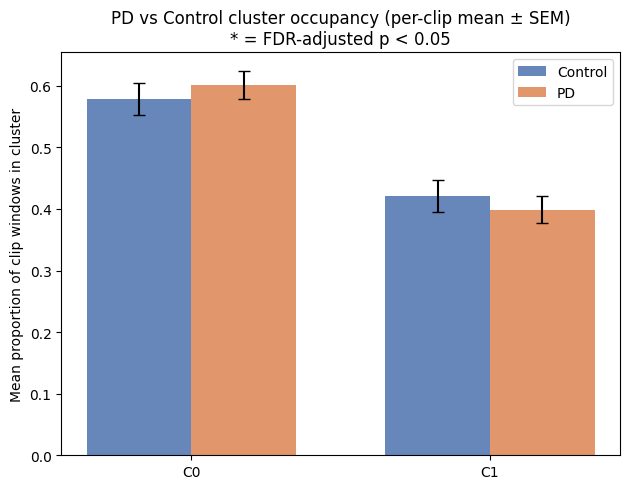

In [33]:
# ============================================================
# PD vs Control comparison within clusters
# Reuses: results, group_labels_arr (built in Cell 3, 1=PD/0=Control),
#         clip_frame_ranges (built in Cell 3)
# NOTE: this notebook has no ON/OFF medication label — group_labels_arr
# is disease status (PD patient vs healthy Control), not med state.
# ============================================================
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

cluster_labels = results['cluster_labels']
windows        = results['windows']
starts = results['window_starts'] # fall back to notebook var if not in results

assert len(cluster_labels) == len(windows) == len(starts), \
    "length mismatch between cluster_labels / windows / starts"

# ── Step 1: build window-level PD/Control label (majority vote per window) ──
window_pd_labels = []
for w in range(len(windows)):
    abs_start = starts[w]
    L         = len(windows[w])
    abs_end   = abs_start + L
    frame_grp = group_labels_arr[abs_start:abs_end]
    vals, counts = np.unique(frame_grp, return_counts=True)
    window_pd_labels.append(vals[np.argmax(counts)])
window_pd_labels = np.array(window_pd_labels)

print(f"Window-level group counts: "
      f"PD={ (window_pd_labels==1).sum() }, Control={ (window_pd_labels==0).sum() }")

# ── Step 2: build window-level clip ID (which clip each window's frames came from) ──
# clip_frame_ranges[i] = (start, end) frame indices for clip i.
# A window is assigned to the clip containing its start frame.
def frame_to_clip(frame_idx):
    for clip_i, (start, end) in enumerate(clip_frame_ranges):
        if start <= frame_idx < end:
            return clip_i
    return -1

window_clip_id = np.array([frame_to_clip(starts[w]) for w in range(len(windows))])
n_unmatched = (window_clip_id == -1).sum()
if n_unmatched:
    print(f"⚠ {n_unmatched} windows didn't match any clip range — check window/frame alignment")

# sanity check: does clip-derived group label agree with window_pd_labels?
clip_group_lookup = np.array([1 if l == 'PD' else 0 for l in labels])  # from Cell 2
mismatch = 0
for w in range(len(windows)):
    if window_clip_id[w] != -1 and window_pd_labels[w] != clip_group_lookup[window_clip_id[w]]:
        mismatch += 1
print(f"Windows where majority-vote group != source-clip group: {mismatch} / {len(windows)}")


# ══════════════════════════════════════════════════════════════════════════
# APPROACH A — naive window-level test (pseudoreplication caveat applies:
# many windows share a clip, so these p-values are likely too optimistic)
# ══════════════════════════════════════════════════════════════════════════
ct = pd.crosstab(pd.Series(cluster_labels, name='cluster'),
                 pd.Series(window_pd_labels, name='group').map({1: 'PD', 0: 'Control'}))
print("\n== Window-level crosstab (cluster x group) ==")
print(ct)

chi2, p_naive, dof, _ = chi2_contingency(ct.values)
print(f"\n[Naive, window-level] χ²({dof})={chi2:.2f}, p={p_naive:.4e}")
print("  ⚠ Treats every window as independent — likely anti-conservative since")
print("    windows from the same clip are correlated with each other.")


# ══════════════════════════════════════════════════════════════════════════
# APPROACH B — clip-aggregated test (each clip contributes ONE proportion
# per cluster, so a clip with many windows doesn't dominate the test)
# ══════════════════════════════════════════════════════════════════════════
df = pd.DataFrame({
    'cluster': cluster_labels,
    'clip_id': window_clip_id,
    'group':   window_pd_labels
})
df = df[df['clip_id'] != -1]

# proportion of each clip's windows falling in each cluster
clip_cluster_props = (
    df.groupby(['clip_id', 'cluster']).size()
      .unstack(fill_value=0)
)
clip_cluster_props = clip_cluster_props.div(clip_cluster_props.sum(axis=1), axis=0)

clip_group = df.groupby('clip_id')['group'].first()  # each clip has one group value
clip_cluster_props['group'] = clip_group

print("\n== Per-clip cluster-occupancy proportions (first 5 clips) ==")
print(clip_cluster_props.head())

results_table = []
cluster_ids = sorted(np.unique(cluster_labels))
for c in cluster_ids:
    if c not in clip_cluster_props.columns:
        continue
    pd_vals   = clip_cluster_props.loc[clip_cluster_props['group'] == 1, c]
    ctrl_vals = clip_cluster_props.loc[clip_cluster_props['group'] == 0, c]
    if len(pd_vals) < 2 or len(ctrl_vals) < 2:
        continue
    stat, p = mannwhitneyu(pd_vals, ctrl_vals, alternative='two-sided')
    results_table.append({
        'cluster': c,
        'n_PD_clips': len(pd_vals), 'n_Control_clips': len(ctrl_vals),
        'median_PD_prop': pd_vals.median(), 'median_Control_prop': ctrl_vals.median(),
        'U_stat': stat, 'p_raw': p
    })

results_df = pd.DataFrame(results_table)
if len(results_df):
    _, p_adj, _, _ = multipletests(results_df['p_raw'], method='fdr_bh')
    results_df['p_fdr'] = p_adj
print("\n[Clip-aggregated, per-cluster] Mann-Whitney U — PD vs Control cluster-occupancy proportion")
print(results_df.round(4).to_string(index=False))


# ══════════════════════════════════════════════════════════════════════════
# PLOT — per-cluster proportion of clips, split by group, with significance
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(2.2 * len(cluster_ids) + 2, 5))
width = 0.35
x = np.arange(len(cluster_ids))

pd_means   = [clip_cluster_props.loc[clip_cluster_props['group']==1, c].mean()
              if c in clip_cluster_props.columns else 0 for c in cluster_ids]
ctrl_means = [clip_cluster_props.loc[clip_cluster_props['group']==0, c].mean()
              if c in clip_cluster_props.columns else 0 for c in cluster_ids]
pd_sem     = [clip_cluster_props.loc[clip_cluster_props['group']==1, c].sem()
              if c in clip_cluster_props.columns else 0 for c in cluster_ids]
ctrl_sem   = [clip_cluster_props.loc[clip_cluster_props['group']==0, c].sem()
              if c in clip_cluster_props.columns else 0 for c in cluster_ids]

ax.bar(x - width/2, ctrl_means, width, yerr=ctrl_sem, label='Control',
       color='#4C72B0', alpha=0.85, capsize=4)
ax.bar(x + width/2, pd_means, width, yerr=pd_sem, label='PD',
       color='#DD8452', alpha=0.85, capsize=4)

if len(results_df):
    for i, c in enumerate(cluster_ids):
        row = results_df[results_df['cluster'] == c]
        if len(row) and row['p_fdr'].values[0] < 0.05:
            y = max(pd_means[i] + pd_sem[i], ctrl_means[i] + ctrl_sem[i]) + 0.02
            ax.text(i, y, '*', ha='center', fontsize=16, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'C{c}' for c in cluster_ids])
ax.set_ylabel('Mean proportion of clip windows in cluster')
ax.set_title('PD vs Control cluster occupancy (per-clip mean ± SEM)\n* = FDR-adjusted p < 0.05')
ax.legend()
plt.tight_layout()
plt.savefig('pd_vs_control_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()